# Cell counts and signal colocalization

This notebook is intentionally a thin driver. Image reading, Cellpose segmentation, channel matching, per-cell measurements, summaries, and file export are implemented in the `colocalize` package.

Before the first run, install the environment with `pip install -r requirements.txt` from the project directory.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from colocalize import (
    AnalysisConfig,
    MaxProjection,
    ReferenceSet,
    SignalChannel,
    build_dataset,
    inspect_inputs,
    run_analysis,
)

## Configuration

Channel numbers are zero-based. You may use metadata channel names instead (for example, `channel="DAPI"`) when the image format provides them. Add another `ReferenceSet` to segment a second reference definition with a different Cellpose model.

In [2]:
config = AnalysisConfig(
    input_dir=Path(r"C:\Users\mzinn1\Desktop\DendrimerColocalization\20260701_GD_9911-9912-9913-9914-9915_20x_Cycle"),
    output_dir=Path(r"C:\Users\mzinn1\Desktop\DendrimerColocalization\RPBMS-GD_counts"),
    reference_sets=[
        ReferenceSet(
            name="RPBMS",
            channel=3,
            model="cpdino_RPBMS",  # Cellpose model-zoo name or custom model path
            diameter=None,   # Set expected diameter in pixels, or leave automatic
        ),
    ],
    signal_channels=[
        SignalChannel(
            name="GD",
            channel=2,
            threshold_method="percentile",  # calibrated from point annotations
            threshold_value=99.5,
            positive_fraction_cutoff=0.05,
        ),
    ],
    transforms=[
        MaxProjection(),
        # Add other transforms here; they run in order.
    ],
    exclude=("Map_A01.oir",),
    device="auto",
)

## Verify inputs

Confirm the discovered files, normalized `C × Y × X` shapes, and channel names before running Cellpose.

In [3]:
inputs = inspect_inputs(config)
inputs

,source,path,shape_cyx,channels
0,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
1,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
2,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
3,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
4,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
5,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
6,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
7,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
8,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
9,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"


## Run analysis

The run writes `cells.csv`, `image_summary.csv`, and one label-mask TIFF per image/reference-set pair.

In [4]:
result = run_analysis(config)

c:\Users\mzinn1\AppData\Local\anaconda3\envs\colocalization\Lib\site-packages\cellpose\dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:823.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


In [5]:
display(result.images)
display(result.cells.head())

,source,reference_set,cell_count,total_cell_area_px,mean_cell_area_px,median_cell_area_px,signal_GD_positive_cell_count,mean_signal_GD_mean
0,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,371,168201,453.371968,420.0,2,177.451739
1,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,274,133669,487.843066,455.5,0,177.128476
2,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,748,260754,348.601604,328.0,1,227.364989
3,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,275,136583,496.665455,478.0,4,369.403669
4,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,542,250490,462.158672,432.0,4,205.569126
5,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,664,323643,487.414157,461.5,6,236.354168
6,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,519,160575,309.393064,290.0,23,467.854732
7,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,534,151881,284.421348,272.0,31,405.579716
8,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,462,138758,300.341991,288.0,20,283.440817
9,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,283,79477,280.837456,265.0,19,371.003278


,source,reference_set,cell_id,centroid_y,centroid_x,area_px,perimeter_px,equivalent_diameter_px,eccentricity,solidity,...,signal_GD_median,signal_GD_max,signal_GD_integrated,signal_GD_positive_area_px,signal_GD_positive_fraction,signal_GD_positive_cell,signal_GD_pearson_r,signal_GD_positive_jaccard,signal_GD_manders_m1_reference,signal_GD_manders_m2_signal
0,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,1,7.698052,600.642857,308,64.870058,19.802974,0.463992,0.962500,...,142.5,382.0,47799.0,0,0.000000,False,-0.072865,0.000000,0.000000,NaN
1,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,2,11.961240,834.436693,387,81.355339,22.197831,0.836434,0.919240,...,115.0,297.0,48359.0,0,0.000000,False,0.011642,0.000000,0.000000,NaN
2,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,3,11.374233,3.914110,163,52.970563,14.406181,0.922177,0.942197,...,158.0,314.0,26098.0,0,0.000000,False,0.061117,0.000000,0.000000,NaN
3,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,4,10.280952,695.028571,420,75.941125,23.124892,0.709810,0.961098,...,134.0,357.0,58414.0,0,0.000000,False,0.029708,0.000000,0.000000,NaN
4,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,RPBMS,5,15.756677,493.866469,674,95.012193,29.294427,0.373590,0.976812,...,191.0,566.0,135934.0,16,0.023739,False,0.044971,0.021053,0.011377,0.171649


## Optional segmentation quality check

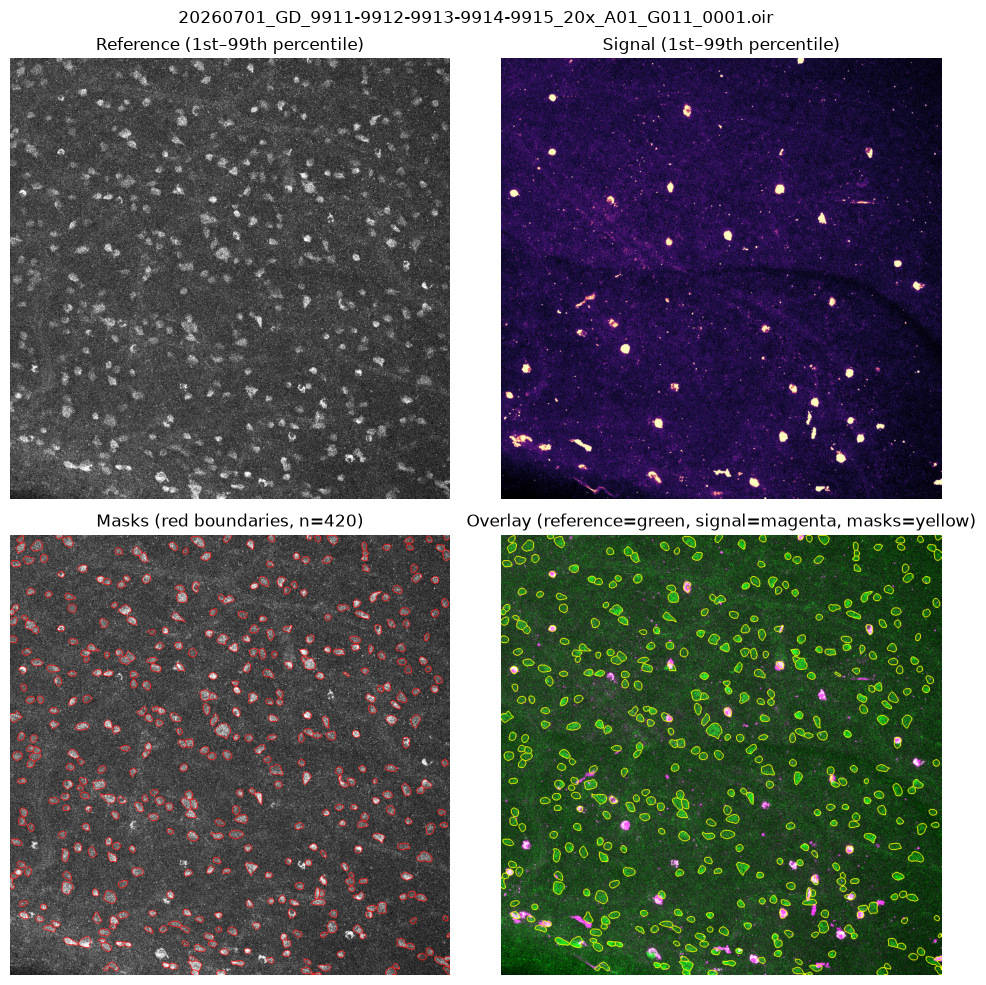

In [6]:
import tifffile
import importlib
from colocalize import visualization

importlib.reload(visualization)
img_number = 10
first_image = build_dataset(config, [inputs.iloc[img_number]["path"]])[0]
first_masks = tifffile.imread(result.mask_paths[img_number])
visualization.show_segmentation(
    first_image.channel(config.reference_sets[0].channel),
    first_masks,
    first_image.channel(config.signal_channels[0].channel),
    title=inputs.iloc[img_number]["source"],
);